<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

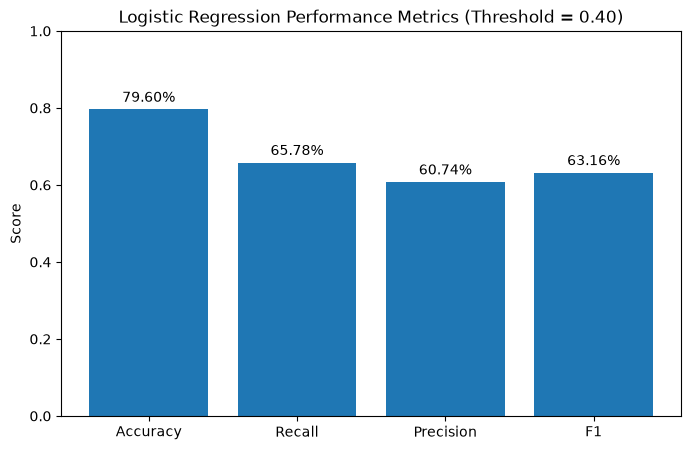

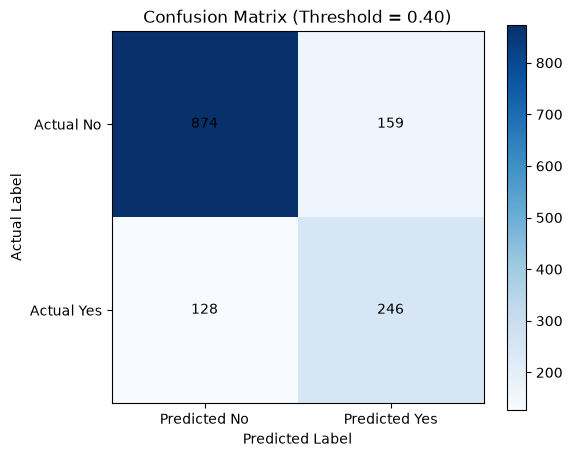

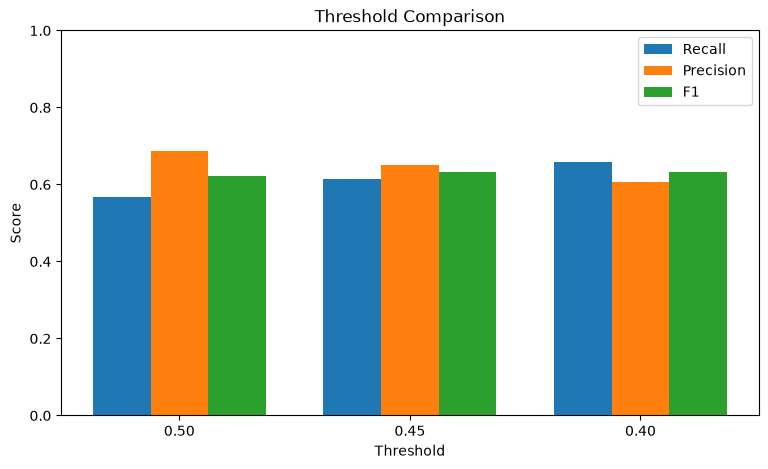

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Import OneHotEncoder to convert categorical data into numbers
from sklearn.preprocessing import OneHotEncoder
# Import LogisticRegression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score, confusion_matrix
# Import RandomForest model
from sklearn.ensemble import RandomForestClassifier
# Import GradientBoosting model
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import cross_validate

from sklearn.metrics import make_scorer
# Import matplotlib for plotting
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("data/Telco-Customer-Churn.csv")
df.head()
df.shape
df.columns
df.info()
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()
df = df.dropna(subset=["TotalCharges"])
df.shape
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]
X.shape
y.shape
# Split the data into training and testing sets
# %80 for training and %20 for testing
# radom_state keep the same random split every time, stratify to keep Churn distribution every yime
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 77, stratify=y
    )
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
# Check the Churn percentage in train and test
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

X_train.dtypes

# Select all categorical columns from the training data
categorical_cols = X_train.select_dtypes(include="str").columns

# Show 
categorical_cols

# Create the OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# Learn the categories from the training data
encoder.fit(X_train[categorical_cols])
# Transform the training categorical data into numbers
X_train_encoded = encoder.transform(X_train[categorical_cols])

# Show the encoded data
X_train_encoded
# Get the names of the new columns created by One-Hot Encoding
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

# Show the new encoded column names
encoded_feature_names
# Convert the encoded training data into a DataFrame
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

# Show the first 5 rows
X_train_encoded_df.head()
# Select the numeric columns from the training data
numerical_cols = X_train.select_dtypes(exclude="str").columns

# Show the numeric column names
numerical_cols
# Combine numeric and encoded categorical features
X_train_ready = pd.concat(
    [X_train[numerical_cols], X_train_encoded_df],
    axis=1
)

# Check the final training data
X_train_ready.head()
# Check the number of rows and columns
X_train_ready.shape

# Transform the test categorical data using the same encoder
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Show the encoded test data
X_test_encoded
# Convert the encoded test data into a DataFrame
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

# Show the first 5 rows
X_test_encoded_df.head()
# Combine numeric and encoded categorical features
X_test_ready = pd.concat(
    [X_test[numerical_cols], X_test_encoded_df],
    axis=1
)

# Check for missing values
print("Missing values in train:", X_train_ready.isnull().sum().sum())
print("Missing values in test:", X_test_ready.isnull().sum().sum())

# Check if any text columns are left
print("Text columns in train:", X_train_ready.select_dtypes(include="str").columns.tolist())

# Check if train and test have the same columns
print("Same columns:", X_train_ready.columns.equals(X_test_ready.columns))

# Check the final shapes
print("Train shape:", X_train_ready.shape)
print("Test shape:", X_test_ready.shape)

model = LogisticRegression(max_iter= 2000) #Create Model

model.fit(X_train_ready, y_train) #Train model

y_pred = model.predict(X_test_ready) #Make Prediction on the test data

accuracy = accuracy_score(y_test, y_pred) # Calculate the model accuracy
print(f"Accuracy: {accuracy:.2%}")

recall = recall_score(y_test, y_pred, pos_label="Yes") # Calculate recall for churn customers
print(f"Recall: {recall:.2%}")

precision = precision_score(y_test,y_pred, pos_label="Yes") # Calculate precision for churn customers
print(f"Precision: {precision:.2%}")

f1 = f1_score(y_test, y_pred, pos_label="Yes") # Calculate f1 for churn customers
print(f"F1: {f1:.2%}")

cm = confusion_matrix(y_test, y_pred) # Calculate Confusion Matrix for churn customers
print(cm)

# Random Forest Model
rf_model = RandomForestClassifier()
rf_model.fit(X_train_ready,y_train)

rf_model_pred = rf_model.predict(X_test_ready)

rf_accuracy = accuracy_score(y_test, rf_model_pred) # Calculate the model accuracy
print(f"Accuracy: {rf_accuracy:.2%}")

rf_recall = recall_score(y_test, rf_model_pred, pos_label="Yes") # Calculate recall for churn customers
print(f"Recall: {rf_recall:.2%}")

rf_precision = precision_score(y_test,rf_model_pred, pos_label="Yes") # Calculate precision for churn customers
print(f"Precision: {rf_precision:.2%}")

rf_f1 = f1_score(y_test, rf_model_pred, pos_label="Yes") # Calculate f1 for churn customers
print(f"F1: {rf_f1:.2%}")

rf_cm = confusion_matrix(y_test, rf_model_pred) # Calculate Confusion Matrix for churn customers
print(rf_cm)

# Gradient Boosting Model
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_ready, y_train)

gb_model_pred = gb_model.predict(X_test_ready)

gb_accuracy = accuracy_score(y_test, gb_model_pred) # Calculate the model accuracy
print(f"Accuracy: {gb_accuracy:.2%}")

gb_recall = recall_score(y_test, gb_model_pred, pos_label="Yes") # Calculate recall for churn customers
print(f"Recall: {gb_recall:.2%}")

gb_precision = precision_score(y_test,gb_model_pred, pos_label="Yes") # Calculate precision for churn customers
print(f"Precision: {gb_precision:.2%}")

gb_f1 = f1_score(y_test, gb_model_pred, pos_label="Yes") # Calculate f1 for churn customers
print(f"F1: {gb_f1:.2%}")

gb_cm = confusion_matrix(y_test, gb_model_pred) # Calculate Confusion Matrix for churn customers
print(gb_cm)


# Create custom scorers for the positive class "Yes"
recall_scorer = make_scorer(recall_score, pos_label="Yes")
f1_scorer = make_scorer(f1_score, pos_label="Yes")

# Store the metrics we want to evaluate
scoring = {
    "recall": recall_scorer,
    "f1": f1_scorer
}

# Run 5-fold cross-validation on the training data
cv_results = cross_validate(
    model,
    X_train_ready,
    y_train,
    cv=5,
    scoring=scoring
)

# Print recall scores for each fold
print("Recall scores:", cv_results["test_recall"])

# Print F1 scores for each fold
print("F1 scores:", cv_results["test_f1"])

# Print the average recall
print(f"Average Recall: {cv_results['test_recall'].mean():.2%}")

# Print the average F1 score
print(f"Average F1: {cv_results['test_f1'].mean():.2%}")

# Get churn probabilities from the Logistic Regression model
churn_probabilities = model.predict_proba(X_test_ready)[:, 1]

# Try different thresholds
thresholds = [0.50, 0.45, 0.40]

# Create an empty list to store the results
results = []

# Test each threshold
for threshold in thresholds:

    # Convert churn probabilities into Yes / No predictions
    threshold_pred = [
        "Yes" if prob >= threshold else "No"
        for prob in churn_probabilities
    ]

    # Calculate accuracy
    threshold_accuracy = accuracy_score(y_test, threshold_pred)

    # Calculate recall for churn customers
    threshold_recall = recall_score(
        y_test,
        threshold_pred,
        pos_label="Yes"
    )

    # Calculate precision for churn customers
    threshold_precision = precision_score(
        y_test,
        threshold_pred,
        pos_label="Yes"
    )

    # Calculate F1 score
    threshold_f1 = f1_score(
        y_test,
        threshold_pred,
        pos_label="Yes"
    )

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, threshold_pred)

    # Get TN, FP, FN, and TP values
    tn, fp, fn, tp = cm.ravel()

    # Save the results for this threshold
    results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Recall": threshold_recall,
        "Precision": threshold_precision,
        "F1": threshold_f1,
        "FN": fn,
        "FP": fp
    })

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Display the threshold comparison table
results_df



# 1. Performance Metrics Bar Chart

# Store metric names
metric_names = ["Accuracy", "Recall", "Precision", "F1"]

# Store final metric values for threshold = 0.40
metric_values = [0.7960, 0.6578, 0.6074, 0.6316]

# Create a new figure
plt.figure(figsize=(8, 5))

# Draw the bar chart
plt.bar(metric_names, metric_values)

# Chart title
plt.title("Logistic Regression Performance Metrics (Threshold = 0.40)")

# Add y-axis label
plt.ylabel("Score")

# Set y-axis range
plt.ylim(0, 1)

# Add percentage values above each bar
for i, value in enumerate(metric_values):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

# Save the chart as an image
plt.savefig("metrics_bar_chart.png", bbox_inches="tight")

# Show the chart
plt.show()

# Close the figure
plt.close()


# 2. Confusion Matrix

# Create the confusion matrix values
cm = np.array([
    [874, 159],
    [128, 246]
])

# Create a new figure
plt.figure(figsize=(6, 5))

# Display the confusion matrix
plt.imshow(cm, interpolation="nearest", cmap="Blues")

# Add chart title
plt.title("Confusion Matrix (Threshold = 0.40)")

# Add color bar
plt.colorbar()

# Add x-axis labels
plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])

# Add y-axis labels
plt.yticks([0, 1], ["Actual No", "Actual Yes"])

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Add axis titles
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Save the chart as an image
plt.savefig("confusion_matrix.png", bbox_inches="tight")

# Show the chart
plt.show()

# Close the figure
plt.close()


# 3. Threshold comparison

# Store the threshold values
threshold_labels = ["0.50", "0.45", "0.40"]

# Store Recall values
recall_values = [0.5668, 0.6150, 0.6578]

# Store Precision values
precision_values = [0.6883, 0.6516, 0.6074]

# Store F1 values
f1_values = [0.6217, 0.6327, 0.6316]

# Create positions for the bars
x = np.arange(len(threshold_labels))

# Set the width of each bar
width = 0.25

# Create a new figure
plt.figure(figsize=(9, 5))

# Draw Recall bars
plt.bar(x - width, recall_values, width, label="Recall")

# Draw Precision bars
plt.bar(x, precision_values, width, label="Precision")

# Draw F1 bars
plt.bar(x + width, f1_values, width, label="F1")

# Add chart title
plt.title("Threshold Comparison")

# Add x-axis label
plt.xlabel("Threshold")

# Add y-axis label
plt.ylabel("Score")

# Add threshold values to x-axis
plt.xticks(x, threshold_labels)

# Set y-axis range
plt.ylim(0, 1)

# Show the legend
plt.legend()

# Save the chart as an image
plt.savefig("threshold_comparison.png", bbox_inches="tight")

# Show the chart
plt.show()

# Close the figure
plt.close()